# Comprehensive Talker Similarity Analysis
Tests different feature layers and distance metrics, and explores gender separation.


In [ ]:
from project_utils import *


In [1]:
import pandas as pd
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from numba import njit
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from scipy.cluster.hierarchy import linkage, leaves_list
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# ----------------- DTW Functions -----------------



# ----------------- Data Prep -----------------
#h5_path = '../data/features/nygaard19_features.h5'
h5_path = '../data/features/nygaard19_tsne_3d_random.h5'
excel_path = '../data/raw_data/alexander_nygaard19/AN19-exposure-test-behavioral-data.xlsx'

print("Loading behavioral data...")
df = pd.read_excel(excel_path, engine='openpyxl')
df['TrainingAccent'] = df['TrainingAccent'].fillna('English')
df['Talker'] = df['FileName'].astype(str).apply(lambda x: x[:3].lower())


df['L1'] = df['Talker'].apply(infer_accent)

unique_recs = df[['Talker', 'L1', 'Word']].drop_duplicates()
word_by_talker = unique_recs.groupby('Talker')['Word'].apply(set).to_dict()

english_talkers = ['ef1', 'ef2', 'ef3', 'em1', 'em2', 'em3']
for et in english_talkers:
    if et not in word_by_talker:
        word_by_talker[et] = set()

GLOBAL_TALKERS = list(word_by_talker.keys())


Loading behavioral data...


In [2]:
def compute_pair_similarity(t1, t2, features_t1, features_t2, dist_type):
    words1 = set(features_t1.keys())
    words2 = set(features_t2.keys())
    shared_words = words1.intersection(words2)
    
    if not shared_words:
        return t1, t2, None
    
    total_sim = 0.0
    count = 0
    dtype_int = 0 if dist_type == 'minkowski' else 1
    
    for w in shared_words:
        feat1 = features_t1[w]
        feat2 = features_t2[w]
        
        dist = dtw_raw_distance(feat1, feat2, tau=2.0, distance_type=dtype_int)
        
        sim = np.exp(-dist * 1.0) 
        total_sim += sim
        count += 1
        
    if count > 0:
        return t1, t2, total_sim / count
    return t1, t2, None

def plot_matrix(ax, sim_matrix, talkers, title):
    sns.heatmap(sim_matrix, xticklabels=talkers, yticklabels=talkers,
                cmap='inferno', square=True, robust=True, ax=ax,
                cbar_kws={'label': 'Average Similarity'})
    
    # Add separating lines
    pos = 0
    groups = ['English', 'Spanish', 'Korean', 'Other']
    for g in groups:
        count = sum(1 for t in talkers if infer_accent(t) == g)
        if count > 0:
            pos += count
            ax.axhline(pos, color='white', linewidth=2)
            ax.axvline(pos, color='white', linewidth=2)
            
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

def analyze_and_plot(layer_name, metric='minkowski', split_gender=False):
    print(f"\n--- Running Analysis: Layer={layer_name}, Metric={metric}, SplitGender={split_gender} ---")
    
    # 1. Load Features
    features = {}
    with h5py.File(h5_path, 'r') as h5f:
        for spk in GLOBAL_TALKERS:
            if spk in h5f:
                features[spk] = {}
                for word in h5f[spk]:
                    if layer_name in h5f[spk][word]:
                        features[spk][word] = h5f[spk][word][layer_name][:]
                        
    valid_talkers = [t for t in GLOBAL_TALKERS if t in features and len(features[t]) > 0]
    
    # 2. Pairwise Calculation
    pairs = [(valid_talkers[i], valid_talkers[j]) for i in range(len(valid_talkers)) for j in range(i+1, len(valid_talkers))]
    print(f"Calculating DTW for {len(pairs)} pairs...")
    
    results = Parallel(n_jobs=-1, prefer='threads')(
        delayed(compute_pair_similarity)(t1, t2, features[t1], features[t2], metric) 
        for t1, t2 in tqdm(pairs, desc=f"{layer_name} {metric}")
    )
    
    pairwise_sims = {}
    for t1, t2, avg_sim in results:
        if avg_sim is not None:
            pairwise_sims[(t1, t2)] = avg_sim
            pairwise_sims[(t2, t1)] = avg_sim
            
    # 3. Construction & Plotting
    def build_ordered_talkers(talker_subset):
        e_talkers = [t for t in talker_subset if infer_accent(t) == 'English']
        s_talkers = [t for t in talker_subset if infer_accent(t) == 'Spanish']
        k_talkers = [t for t in talker_subset if infer_accent(t) == 'Korean']
        o_talkers = [t for t in talker_subset if infer_accent(t) == 'Other']
        
        # Cluster 'Other' talkers
        if len(o_talkers) > 1:
            n_o = len(o_talkers)
            dist_mat = np.zeros((n_o, n_o))
            for i, t1 in enumerate(o_talkers):
                for j, t2 in enumerate(o_talkers):
                    if i != j:
                        dist_mat[i, j] = 1.0 - pairwise_sims.get((t1, t2), 0.0)
            condensed = []
            for i in range(n_o):
                for j in range(i+1, n_o):
                    condensed.append(dist_mat[i, j])
            if np.any(np.isnan(condensed)): condensed = np.nan_to_num(condensed, nan=1.0)
            try:
                Z = linkage(condensed, method='average')
                order = leaves_list(Z)
                o_talkers = [o_talkers[i] for i in order]
            except Exception:
                pass
                
        return e_talkers + s_talkers + k_talkers + o_talkers

    def build_matrix(talker_list):
        n = len(talker_list)
        mat = np.zeros((n, n))
        for i, t1 in enumerate(talker_list):
            for j, t2 in enumerate(talker_list):
                if i == j:
                    mat[i, j] = np.nan
                else:
                    mat[i, j] = pairwise_sims.get((t1, t2), 0.0)
        return mat

    if split_gender:
        females = [t for t in valid_talkers if t[1] == 'f']
        males = [t for t in valid_talkers if t[1] == 'm']
        
        ord_females = build_ordered_talkers(females)
        ord_males = build_ordered_talkers(males)
        
        mat_f = build_matrix(ord_females)
        mat_m = build_matrix(ord_males)
        
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        plot_matrix(axes[0], mat_f, ord_females, f"{layer_name} - {metric} (Females)")
        plot_matrix(axes[1], mat_m, ord_males, f"{layer_name} - {metric} (Males)")
        plt.tight_layout()
        plt.show()
    else:
        ord_all = build_ordered_talkers(valid_talkers)
        mat_all = build_matrix(ord_all)
        
        fig, ax = plt.subplots(figsize=(10, 8))
        plot_matrix(ax, mat_all, ord_all, f"{layer_name} - {metric} (All Talkers)")
        plt.tight_layout()
        plt.show()



--- Running Analysis: Layer=tr_24, Metric=minkowski, SplitGender=True ---
Calculating DTW for 861 pairs...


tr_24 minkowski:   0%|          | 0/861 [00:00<?, ?it/s]

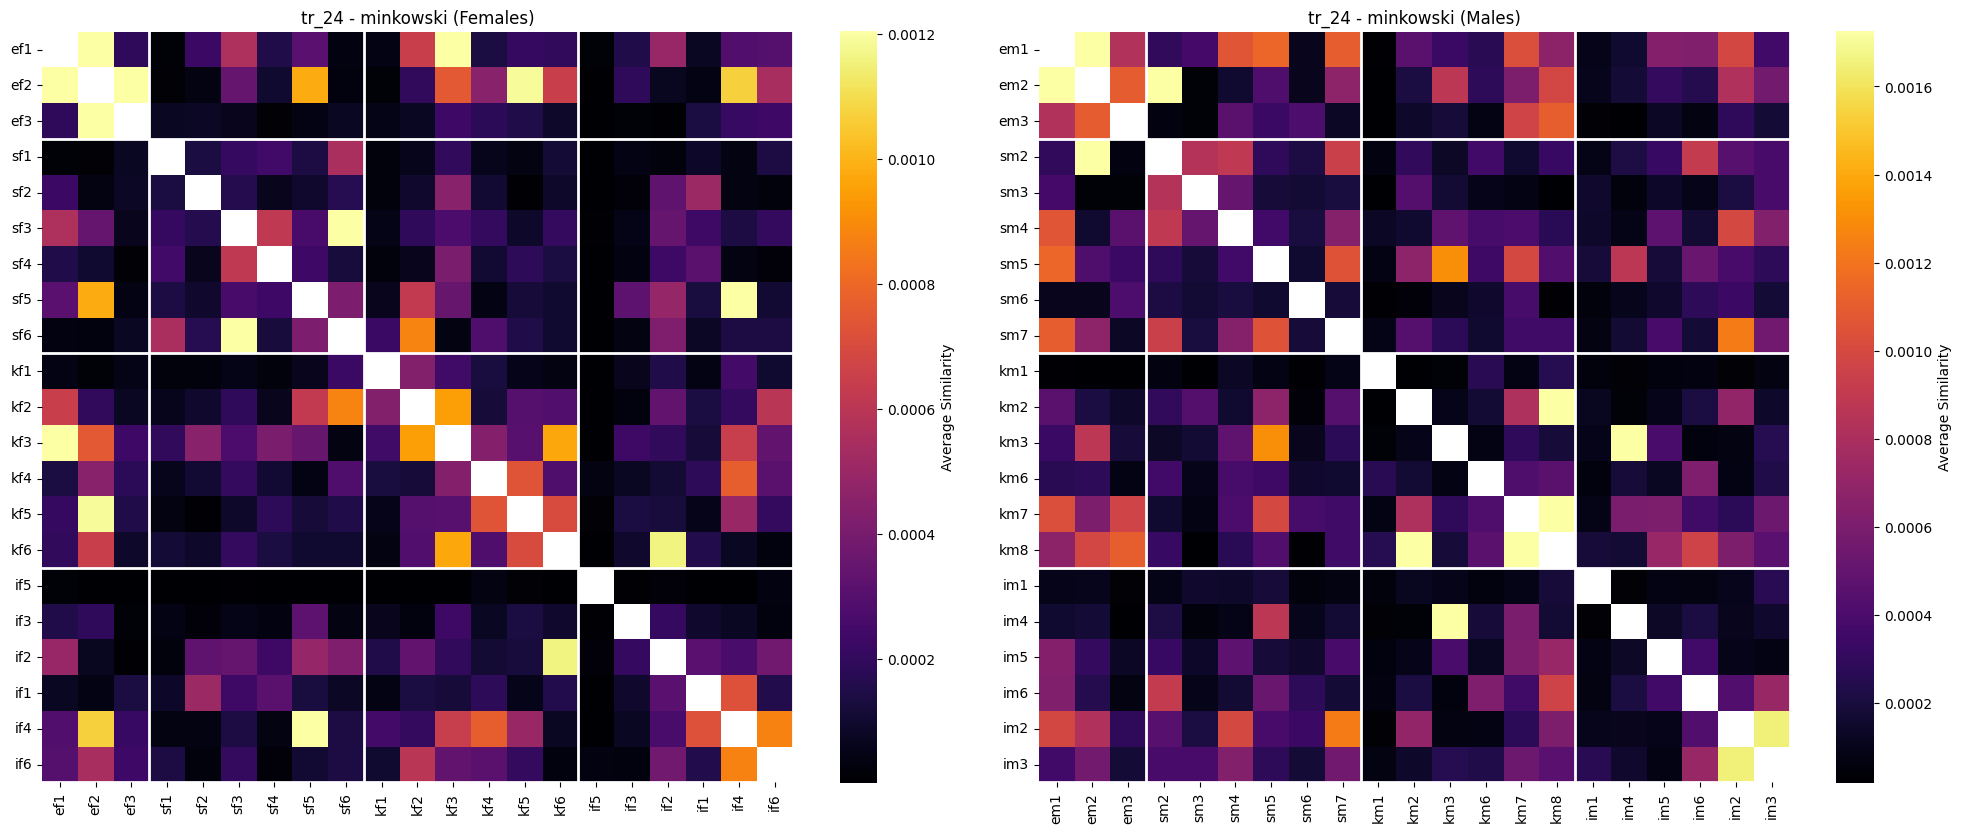

In [3]:
# Test 1: tr_24, Minkowski, Split Genders
analyze_and_plot('tr_24', metric='minkowski', split_gender=True)



--- Running Analysis: Layer=cnn_2, Metric=minkowski, SplitGender=False ---
Calculating DTW for 861 pairs...


cnn_2 minkowski:   0%|          | 0/861 [00:00<?, ?it/s]

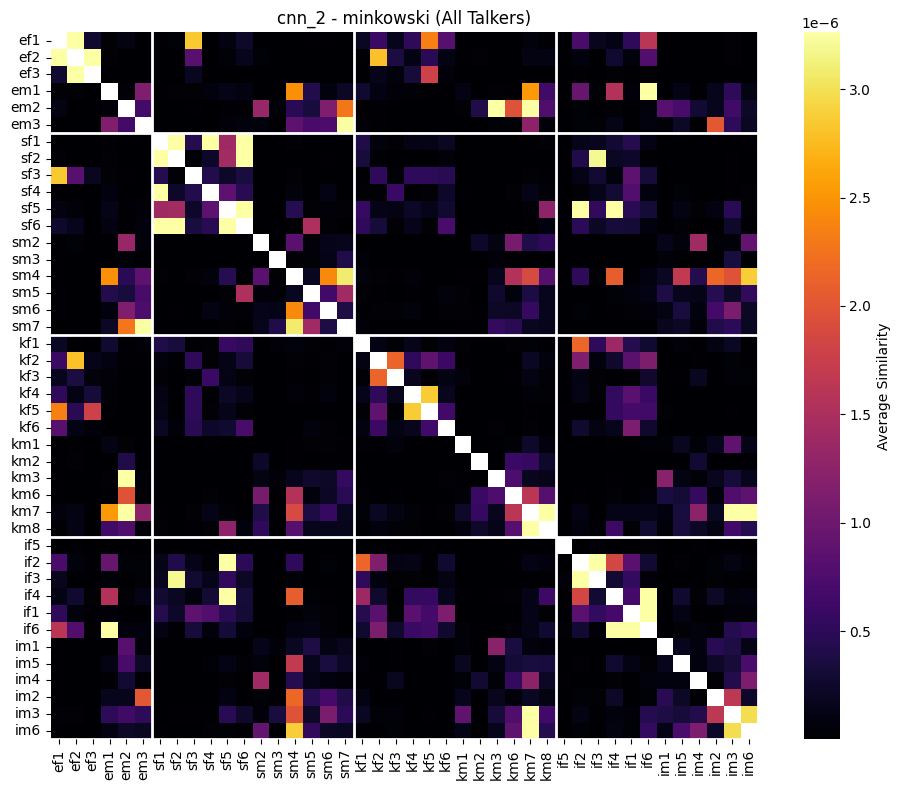

In [4]:
# Test 2: cnn_2, Minkowski, All
analyze_and_plot('cnn_2', metric='minkowski', split_gender=False)



--- Running Analysis: Layer=cnn_6, Metric=minkowski, SplitGender=False ---
Calculating DTW for 861 pairs...


cnn_6 minkowski:   0%|          | 0/861 [00:00<?, ?it/s]

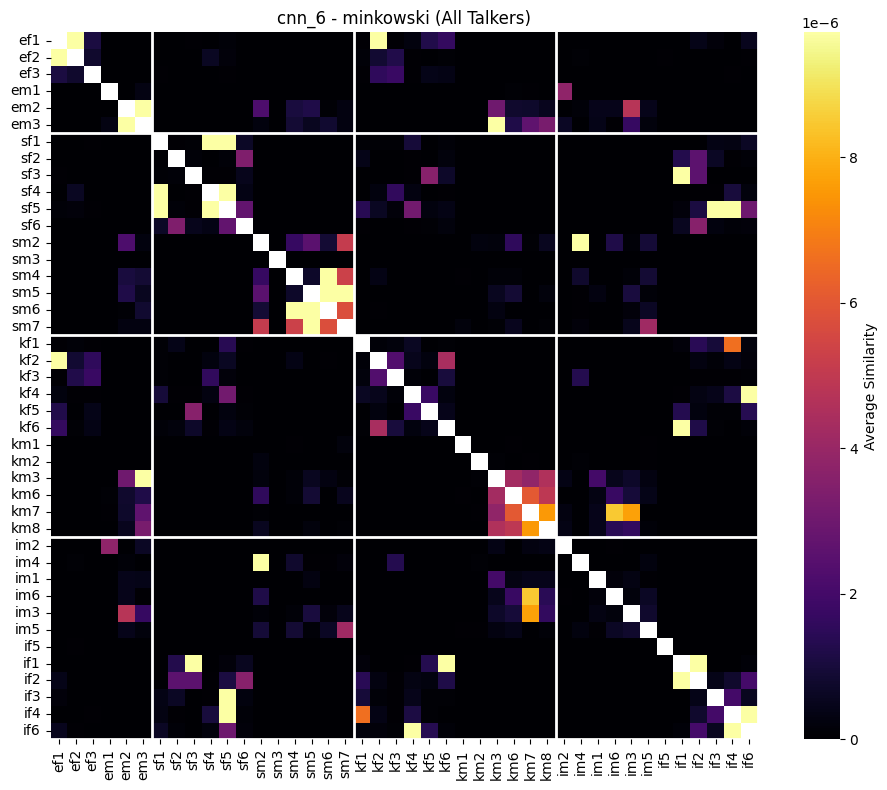

In [5]:
# Test 3: cnn_6, Minkowski, All
analyze_and_plot('cnn_6', metric='minkowski', split_gender=False)



--- Running Analysis: Layer=tr_12, Metric=minkowski, SplitGender=False ---
Calculating DTW for 861 pairs...


tr_12 minkowski:   0%|          | 0/861 [00:00<?, ?it/s]

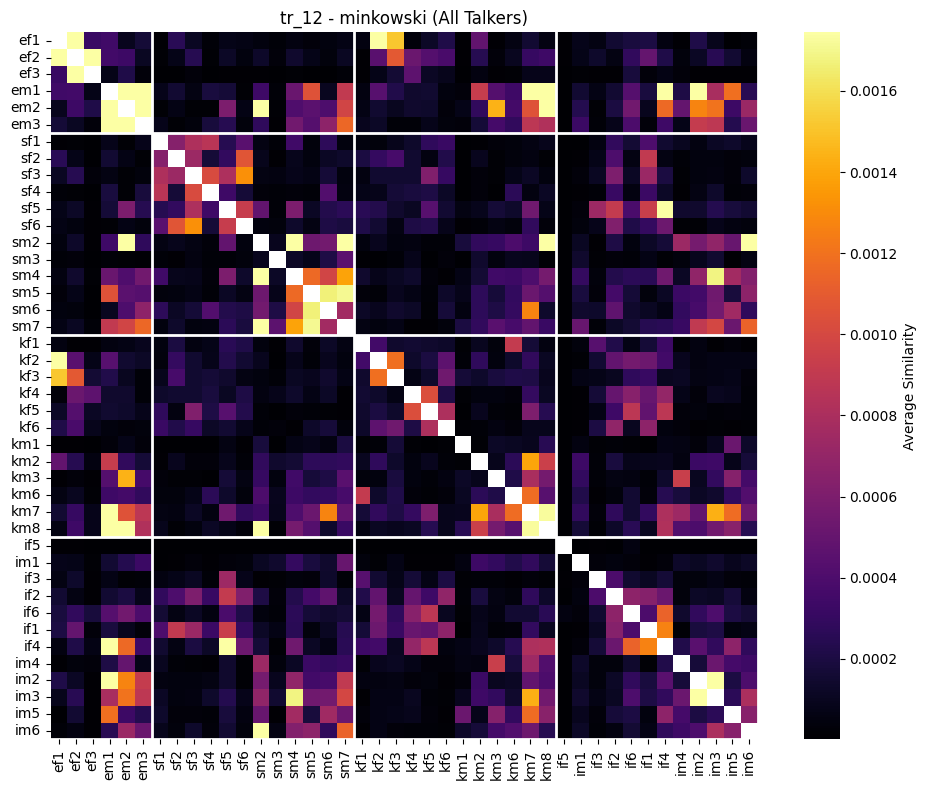

In [6]:
# Test 4: tr_12, Minkowski, All
analyze_and_plot('tr_12', metric='minkowski', split_gender=False)



--- Running Analysis: Layer=tr_24, Metric=cosine, SplitGender=False ---
Calculating DTW for 861 pairs...


tr_24 cosine:   0%|          | 0/861 [00:00<?, ?it/s]

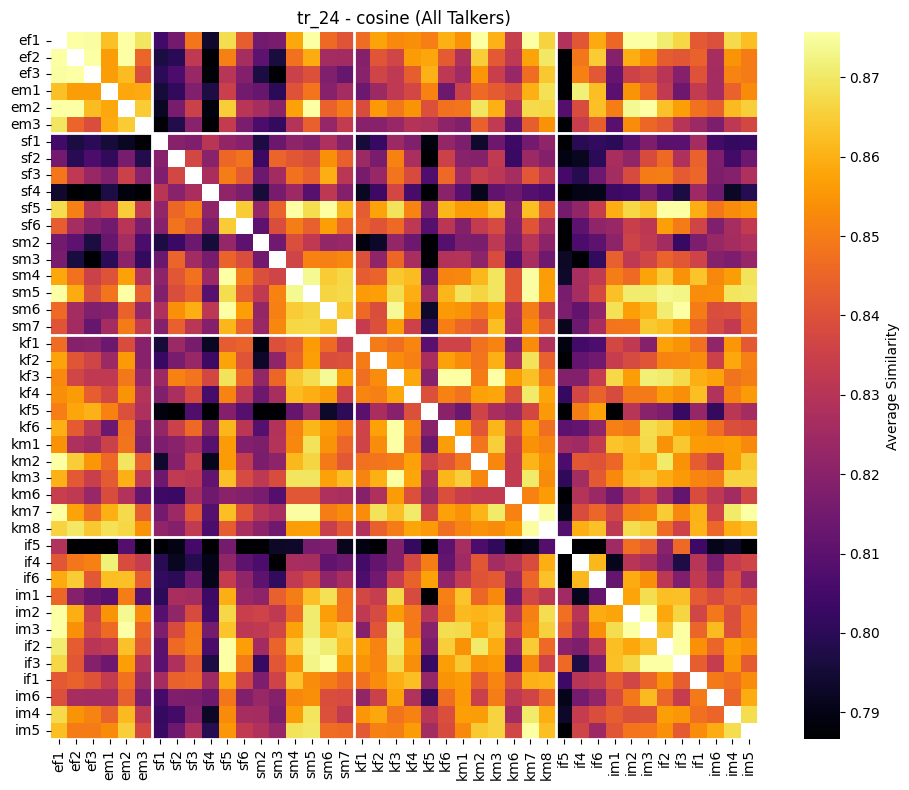

In [7]:
# Test 5: tr_24, Cosine, All
analyze_and_plot('tr_24', metric='cosine', split_gender=False)


### Archived Script: `an19_talker_similarity.py`
The following code was migrated from a standalone `.py` script during project reorganization.

In [ ]:
import pandas as pd
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from numba import njit
from scipy.cluster.hierarchy import linkage, leaves_list



def main():
    h5_path = '../data/features/nygaard19_features.h5'
    excel_path = '../data/raw_data/alexander_nygaard19/AN19-exposure-test-behavioral-data.xlsx'
    layer_name = 'cnn_6' # Could use cnn_1 or others, using cnn_6 as default
    
    print("Loading behavioral data...")
    # Using openpyxl explicitly and suppressing warnings
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df = pd.read_excel(excel_path, engine='openpyxl')
    
    # Extract Speaker (first 3 chars of FileName, lowercase), Accent, Word
    df['Talker'] = df['FileName'].astype(str).apply(lambda x: x[:3].lower())
    
    # English talkers might have accent as 'Control' or 'English', etc.
    if 'Accent' in df.columns:
        df['L1'] = df['Accent'].astype(str)
    else:
        df['L1'] = 'Unknown'
        
    # We define Accent purely by speaker initials if Accent column is tricky
    def infer_accent(spk):
        if spk.startswith('e'): return 'English'
        elif spk.startswith('s'): return 'Spanish'
        elif spk.startswith('k'): return 'Korean'
        return 'Other'
        
    df['L1'] = df['Talker'].apply(infer_accent)
    
    # 1 & 2. Get unique combinations of Talker, L1, Word
    unique_recs = df[['Talker', 'L1', 'Word']].drop_duplicates()
    
    # 5. Group by matching words.
    word_by_talker = unique_recs.groupby('Talker')['Word'].apply(set).to_dict()
    all_talkers = list(word_by_talker.keys())
    
    print("Loading features...")
    features = {} # {talker: {word: feature_matrix}}
    with h5py.File(h5_path, 'r') as h5f:
        for spk in all_talkers:
            if spk in h5f:
                features[spk] = {}
                for word in h5f[spk]:
                    if layer_name in h5f[spk][word]:
                        features[spk][word] = h5f[spk][word][layer_name][:]
                        
    print(f"Features loaded for {len(features)} talkers.")

    # 3. Calculate all pairwise similarities
    print("Calculating pairwise similarities (tau=2, k=1)...")
    pairwise_sims = {}
    
    # Filter talkers to only those we have features for
    valid_talkers = [t for t in all_talkers if t in features and len(features[t]) > 0]
    
    total_pairs = len(valid_talkers) * (len(valid_talkers) - 1) // 2
    processed = 0
    
    for i, t1 in enumerate(valid_talkers):
        for j, t2 in enumerate(valid_talkers):
            if i >= j: continue
            
            words1 = set(features[t1].keys())
            words2 = set(features[t2].keys())
            shared_words = words1.intersection(words2)
            
            if not shared_words:
                processed += 1
                continue
            
            total_sim = 0.0
            count = 0
            for w in shared_words:
                feat1 = features[t1][w]
                feat2 = features[t2][w]
                
                dist = dtw_raw_distance(feat1, feat2, tau=2.0)
                sim = np.exp(-dist * 1.0) # k = 1
                total_sim += sim
                count += 1
                
            if count > 0:
                avg_sim = total_sim / count
                pairwise_sims[(t1, t2)] = avg_sim
                pairwise_sims[(t2, t1)] = avg_sim
                
            processed += 1
            if processed % 100 == 0:
                print(f"Processed {processed}/{total_pairs} pairs...")
                
    # 4 & 6. Matrix Construction & Clustering
    l1_map = unique_recs.groupby('Talker')['L1'].first().to_dict()
    
    english_talkers = [t for t in valid_talkers if l1_map.get(t, '') == 'English']
    spanish_talkers = [t for t in valid_talkers if l1_map.get(t, '') == 'Spanish']
    korean_talkers = [t for t in valid_talkers if l1_map.get(t, '') == 'Korean']
    other_talkers = [t for t in valid_talkers if l1_map.get(t, '') == 'Other']
    
    # Order 'other_talkers' by average similarity
    if len(other_talkers) > 1:
        n_other = len(other_talkers)
        dist_matrix = np.zeros((n_other, n_other))
        for i, t1 in enumerate(other_talkers):
            for j, t2 in enumerate(other_talkers):
                if i == j:
                    dist_matrix[i, j] = 0.0
                else:
                    sim = pairwise_sims.get((t1, t2), 0.0)
                    dist_matrix[i, j] = 1.0 - sim # Distance for clustering
                    
        condensed_dist = []
        for i in range(n_other):
            for j in range(i+1, n_other):
                condensed_dist.append(dist_matrix[i, j])
                
        # Handle case where condensed_dist might have NaNs or all zeros
        if np.any(np.isnan(condensed_dist)):
            print("Warning: NaN in distance matrix. Filling with 1.0")
            condensed_dist = np.nan_to_num(condensed_dist, nan=1.0)
            
        try:
            Z = linkage(condensed_dist, method='average')
            order = leaves_list(Z)
            other_talkers = [other_talkers[i] for i in order]
        except Exception as e:
            print(f"Clustering failed: {e}. Keeping original order.")
        
    ordered_talkers = english_talkers + spanish_talkers + korean_talkers + other_talkers
    
    n_total = len(ordered_talkers)
    sim_matrix = np.zeros((n_total, n_total))
    
    for i, t1 in enumerate(ordered_talkers):
        for j, t2 in enumerate(ordered_talkers):
            if i == j:
                sim_matrix[i, j] = 1.0
            else:
                sim_matrix[i, j] = pairwise_sims.get((t1, t2), 0.0)
                
    print(f"\nTalker Grouping ({n_total} total):")
    print(f"  English: {len(english_talkers)}")
    print(f"  Spanish: {len(spanish_talkers)}")
    print(f"  Korean:  {len(korean_talkers)}")
    print(f"  Other:   {len(other_talkers)}")
                
    # 5. Visualization
    plt.figure(figsize=(12, 10))
    ax = sns.heatmap(sim_matrix, xticklabels=ordered_talkers, yticklabels=ordered_talkers,
                     cmap='inferno', square=True, 
                     cbar_kws={'label': 'Average Talker-to-Talker Similarity (exp(-d))'})
    
    # Add white lines to separate L1 groups
    pos = 0
    for group in [english_talkers, spanish_talkers, korean_talkers]:
        if len(group) > 0:
            pos += len(group)
            ax.axhline(pos, color='white', linewidth=2)
            ax.axvline(pos, color='white', linewidth=2)
            
    plt.title(f'AN19 Talker-to-Talker Average Pairwise Similarity\nFeatures: {layer_name}, tau=2, k=1', fontsize=14)
    plt.xlabel('Talker', fontsize=12)
    plt.ylabel('Talker', fontsize=12)
    
    # Rotate xticklabels
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    
    output_path = 'an19_talker_similarity_heatmap.png'
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    print(f"Heatmap saved to {output_path}")

if __name__ == '__main__':
    main()

